# 2.8 Multi-Agent 시스템과 RouteLLM

- 앞에서 개발한 `소득세 에이전트`와 `종합부동산세 에이전트`를 활용해서 다중 에이전트 시스템을 구현합니다

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

small_llm = ChatOpenAI(model='gpt-4o-mini')

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str
    
graph_builder = StateGraph(AgentState)

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'."""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['income_tax', 'real_estate_tax', 'llm']:
    """
    주어진 state에서 쿼리를 기반으로 적절한 경로를 결정합니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        Literal['income_tax', 'real_estate_tax', 'llm']: 쿼리에 따라 선택된 경로를 반환합니다.
    """
    query = state['query']
    router_chain = router_prompt | structured_router_llm 
    route = router_chain.invoke({'query': query})

    return route.target

In [12]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState) -> AgentState:
    """
    주어진 state에서 쿼리를 LLM에 전달하여 응답을 얻습니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'answer' 키를 포함하는 새로운 state를 반환합니다.
    """
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

- `node`를 추가하고 `edge`로 연결합니다
    - 앞에서 개발한 `agent`들을 `node`로 활용할 수 있습니다

In [13]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

In [14]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm'
    }
)
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [15]:
graph = graph_builder.compile()

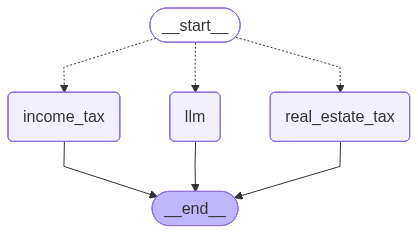

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

{'query': '소득세란 무엇인가요?',
 'context': [Document(metadata={'source': './documents/income_tax.txt'}, page_content='①조 세특례제한법, 또는 이 법 제12조에 따른 과세제외 소득  \n대통령령으로 정하는 임금소득(이하 “임금소득”이라 한다)과 근로소득  \n\n제12조제2항의 세호에 따라 원천징수하는 이자소득 및 배당소득과 제16조제1항제10호에 따른 직장공제회초 관련소득  \n\n\n법인으로 보는 단체 외의 단체 중 소득을 구성함에 배분하지 아니하는 단체로서 단체를 표기하는 금융거래를 하는 단체가 “금융신용기관” 및 비임금소득에 관한 법령이 제20조제1항 목의 이후에 해당하는 금융사업을 하는 단체(이하 “금융회사”等이란)로부터 받은 이자소득 및 배당소득  \n\n\n①조 세특례제한법에 따른 보통계소득  \n\n\n제30조부터 제35조까지의 규정 외의 이자소득과 배당소득(제17조제1항제8호에 따른 배당소득을 제외한다)으로서 그 소득의 합계액이 2천만원(이하 “이자소득의 종합세액기준금액”이라 한다) 이하인 경우 제17조에 따른 원천징수된 소득  \n\n\n해당 과세기간에 배당행정을 정하는 총수입금액의 합계액이 2천만원 이하인 자의 주택임대소득(이하 “분리과세 주택임대소득”이라 한다). 이 경우 주택임대소득이 산정 등에 필요한 대책행령으로 정한다.  \n\n\n다음 각 목 외의 기타소득(이하 “분리과세 기타소득”이라 한다)  \n\n\n가. 제21조제1항제3호 제4항, 제19조, 제20조제1항, 제22조제2항, 제26조 및 제26조의2 및 제 127조에 따라 원천징수(제21조제19항에 의하여 원천징수되지 아니하는 경우를 포함한다) 소득. 다만, 해당 소득이 있는 거주자가 종합소득과세표준을 계산해 고소득을 합산하는 경우 그 소득은 분리과세로 세액계산에 제외한다.  \n나. 제21조제19항제2조 및 같은 조 제2항에 따른 기타소득  \n다. 제21조제19항제20호에 따른 기타소득 중 

In [18]:
initial_state = {
    'query': '집 15억은 세금을 얼마나 내나요?'
}

graph.invoke(initial_state)

{'query': '집 15억은 세금을 얼마나 내나요?',
 'answer': '주어진 정보에 따르면, 주택의 공시가격이 15억 원이고 공정시장가액비율이 60%이므로 과세표준은 9억 원입니다. 종합부동산세를 계산하기 위해서는 과세표준에 따른 세율을 적용해야 합니다.\n\n주택에 대한 종합부동산세는 다음과 같은 세율 구간을 적용합니다. (일반적인 경우로, 구체적인 법령이나 상황에 따라 다를 수 있습니다.)\n\n- 6억 원 초과 12억 원 이하: 0.5% ~ 2.7%\n- 12억 원 초과 50억 원 이하: 1.0% ~ 4.0%\n\n과세표준이 9억 원이므로 6억 원 초과 12억 원 이하 구간에 해당합니다. 이 구간에 대한 세율은 상황에 따라 다르게 적용될 수 있습니다. 예를 들어, 기본 세율이 1.0%라고 가정하면:\n\n1. 세액 = 과세표준 × 세율\n   - 세액 = 9억 원 × 1.0% = 9,000,000원\n\n따라서, 공제 항목이 없고 기본 세율을 1.0%로 가정했을 때, 종합부동산세는 900만 원이 됩니다. 구체적인 세율이나 공제 항목은 세무 전문가와 상담하여 확인하는 것이 좋습니다.'}

In [19]:
initial_state = {'query': '떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

{'query': '떡볶이는 어디가 맛있나요?',
 'answer': '떡볶이는 한국의 대표적인 길거리 음식으로, 지역마다 다양한 맛과 스타일이 있습니다. 다음은 떡볶이가 맛있는 곳으로 유명한 몇 가지 지역입니다:\n\n1. **서울**: \n   - **신당동 떡볶이 타운**: 다양한 떡볶이 가게가 밀집해 있어 여러 가지 스타일의 떡볶이를 맛볼 수 있습니다.\n   - **강남역**: 여러 유명 떡볶이 가게가 있어 쇼핑 후 간편하게 즐기기 좋습니다.\n\n2. **부산**:\n   - **자갈치 시장**: 해산물 떡볶이가 유명하며, 신선한 재료로 만든 떡볶이를 맛볼 수 있습니다.\n   - **서면**: 젊은 층이 많이 찾는 지역으로, 다양한 퓨전 떡볶이 가게가 있습니다.\n\n3. **대구**:\n   - **대구 동성로**: 거리 음식으로 유명하며, 다양한 떡볶이 가게가 있어 선택의 폭이 넓습니다.\n\n4. **전주**:\n   - **전주 한옥마을**: 전통적인 떡볶이를 즐길 수 있는 가게가 많습니다.\n\n각 지역마다 고유의 맛과 스타일이 있으니, 여행 중에 다양한 떡볶이를 시도해보는 것도 좋습니다!'}